In [5]:
import os
import sys
sys.path.insert(0, "/hkfs/work/workspace/scratch/cc7738-automorphism/ANP4Link/")
import numpy as np
import torch
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import k_hop_subgraph, to_networkx
from torch_geometric.data import Data
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.typing import Adj
from torch_geometric.utils import (
    degree,
    is_sparse,
    scatter,
    sort_edge_index,
    to_edge_index,
    from_networkx,
    to_networkx,
    train_test_split_edges,
    to_undirected
)
from syn_real.disjoint_syn import (create_disjoint_graph,
                                    get_graph_orbits,
                                    add_random_edges,
                                    plot_graph_with_orbits)

from torch_geometric.data import Data
from syn_real.disjoint_syn import (semi_autom_expt,
                                   hash_links_by_orbit)
from syn_real.mot import (
    run_wl_test_and_group_nodes,
    compute_automorphism_metrics,
    count_orbit_edges,
    plot_orbit,
    plot_triangular_graph
)
from collections import Counter

In [ ]:

def get_k_hop_subgraph_from_dataset(dataset_name="Cora", num_hops=4, node_idx=0, visualize=True):
    """
    Load a dataset and extract a k-hop subgraph around a given node.
    
    Args:
        dataset_name (str): e.g. "Cora", "Citeseer", "PubMed"
        num_hops (int): Number of hops to include in the subgraph
        node_idx (int): Center node to extract from
        visualize (bool): If True, visualize the subgraph

    Returns:
        Data: PyG Data object of the subgraph
    """
    # Load dataset
    dataset = Planetoid(root=f'/tmp/{dataset_name}', name=dataset_name)
    data = dataset[0]


    # Extract k-hop subgraph
    subset, sub_edge_index, mapping, edge_mask = k_hop_subgraph(
        node_idx=node_idx,
        num_hops=num_hops,
        edge_index=data.edge_index,
        relabel_nodes=True,
        num_nodes=data.num_nodes
    )

    # Create subgraph Data object
    sub_x = data.x[subset]
    sub_y = data.y[subset]
    sub_data = Data(x=sub_x, edge_index=sub_edge_index, y=sub_y)

    # Optional visualization
    if visualize:
        G_sub = to_networkx(sub_data, to_undirected=True)
        plt.figure(figsize=(8, 6))
        nx.draw(G_sub, with_labels=True, node_size=300, node_color='skyblue', edge_color='gray')
        plt.title(f"{num_hops}-Hop Subgraph from Node {node_idx} ({dataset_name})")
        plt.axis('off')
        plt.show()

    return sub_data



def plot_orbit_dist(node_groups):
    node_dist = {}
    for node, label in enumerate(node_groups):
        if label not in node_dist:
            node_dist[label] = []
        node_dist[label].append(node)
        
    group_sizes = np.array([len(group) for group in node_dist.values()])
    

    plt.figure(figsize=(6, 4))
    plt.hist(group_sizes, bins=range(min(group_sizes), max(group_sizes) + 2), align='left', rwidth=0.8)
    plt.xlabel('Orbit Label')
    plt.ylabel('Frequency')
    plt.title('Histogram of Orbit Size (Dist of Dist)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    # plt.savefig(f"{name}_distribution_d{depth}.pdf")
    plt.close()



def count_automorphic_edges(G, node_groups):
    """
    Counts intra-orbit and inter-orbit edges in a graph G based on node_groups,
    excluding nodes that are the only ones in their group.

    Parameters:
        G (networkx.Graph): The input graph.
        node_groups (list): A list where the index is the node ID and the value is the orbit/group ID.

    Returns:
        tuple: (intra_orbit_edges, inter_orbit_edges)
    """
    group_counts = Counter(node_groups)
    valid_nodes = {i for i, group in enumerate(node_groups) if group_counts[group] == 1}

    # print(f"unique orbit node: {len(valid_nodes)}")
    intra_orbit_edges = 0
    inter_orbit_edges = 0
    for u, v in G.edges():
        if u in valid_nodes and v in valid_nodes:
            continue 
        if node_groups[u] == node_groups[v]:
            intra_orbit_edges += 1
        else:
            inter_orbit_edges += 1
    # print(f"Intra-orbit edges: {intra_orbit_edges}, Inter-orbit edges: {inter_orbit_edges}")
    print(f"Non-distinguishable edges: {intra_orbit_edges+inter_orbit_edges}")
    return intra_orbit_edges, inter_orbit_edges


def analyze_automorphisms(G):

    data = from_networkx(G)
    _, node_labels, orbits = run_wl_test_and_group_nodes(data.edge_index, num_nodes=data.num_nodes, num_iterations=100)
    # orbits, num_orbit = get_graph_orbits(G)
    # print(f"Number of orbits: {num_orbit}")

    custom_labels = {}
    for i, ov in zip(G.nodes(), orbits):
            custom_labels[i] = f"{ov}"

    count_automorphic_edges(G, orbits)
    
    metrics, num_nodes, group_sizes = compute_automorphism_metrics(orbits, G.number_of_nodes())
    
    plot_orbit_dist(orbits)
    plot_orbit(orbits)
    hash_links_by_orbit(G, orbits)
    plot_graph_with_orbits(G, 
                           None, 
                           orbits, 
                           custom_labels=custom_labels, 
                           figsize=(8, 6), cmap='tab20b')
    return metrics, num_nodes, group_sizes, orbits

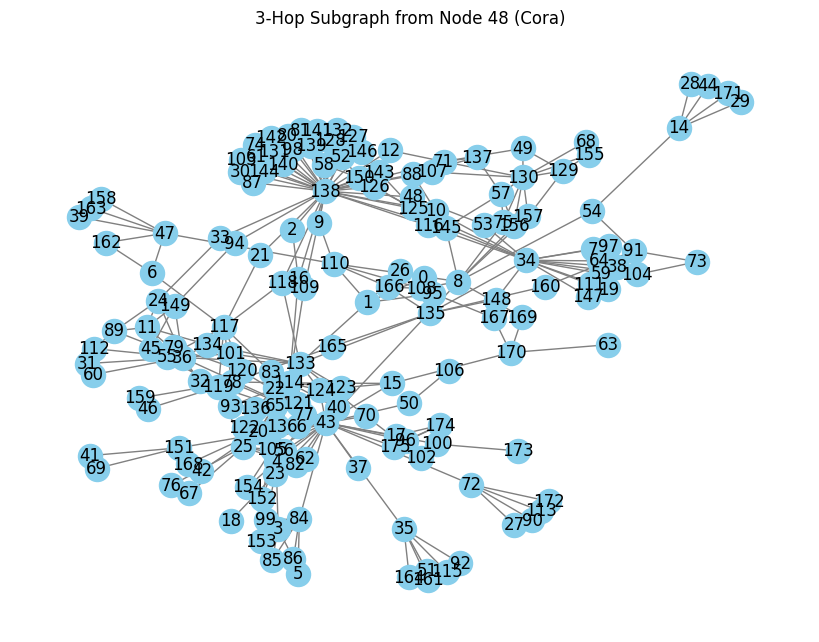

Data(x=[176, 1433], edge_index=[2, 592], y=[176])
Subgraph labels: torch.Size([176])


In [10]:
if __name__ == '__main__':

    # Example usage
    subgraph = get_k_hop_subgraph_from_dataset(dataset_name="Cora", num_hops=3, node_idx=48, visualize=True)
    print(subgraph)
    print("Subgraph labels:", subgraph.y.shape)

Number of nodes in the graph: 176
Non-distinguishable edges: 296


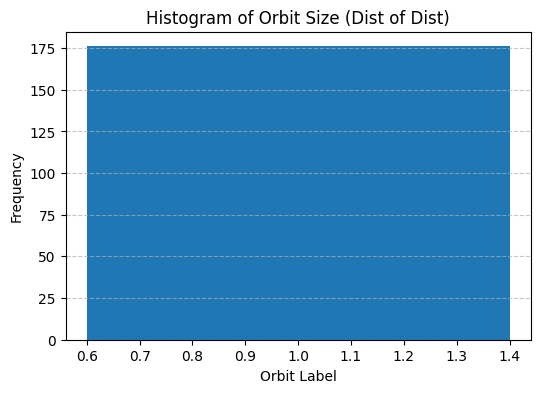

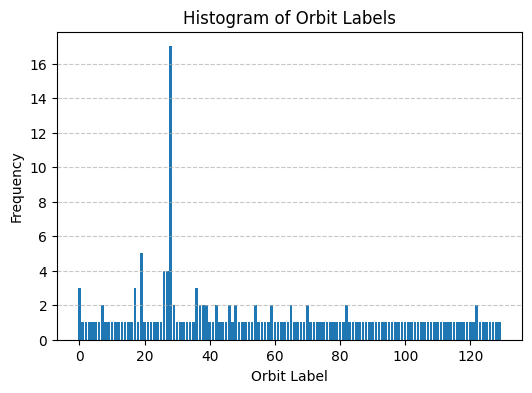

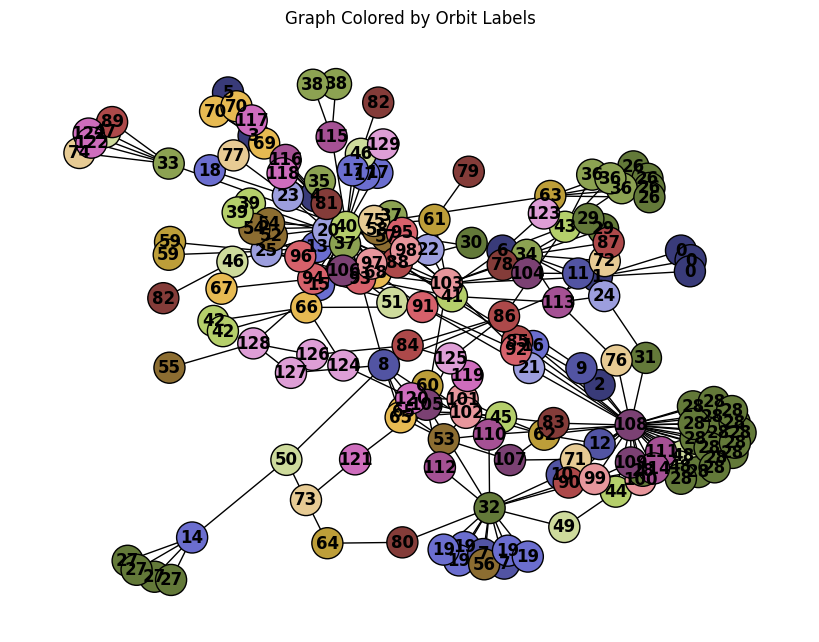

torch.Size([2, 6])
Non-distinguishable edges: 302


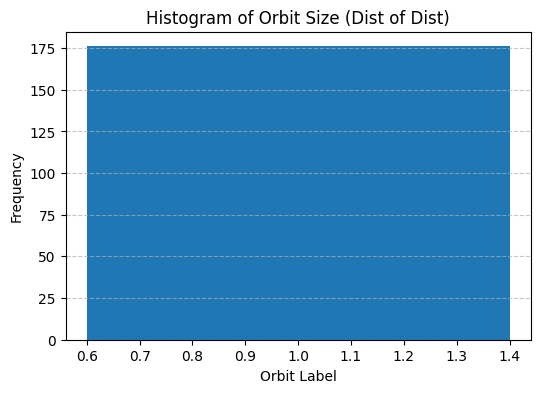

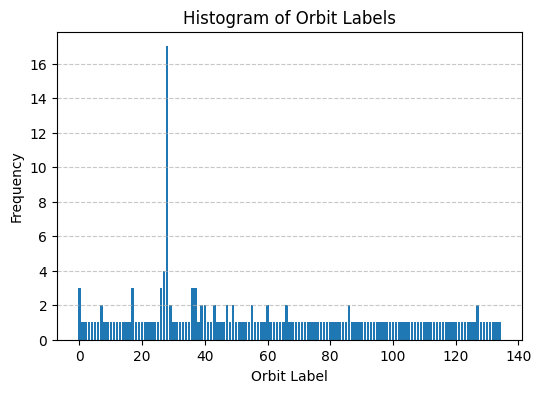

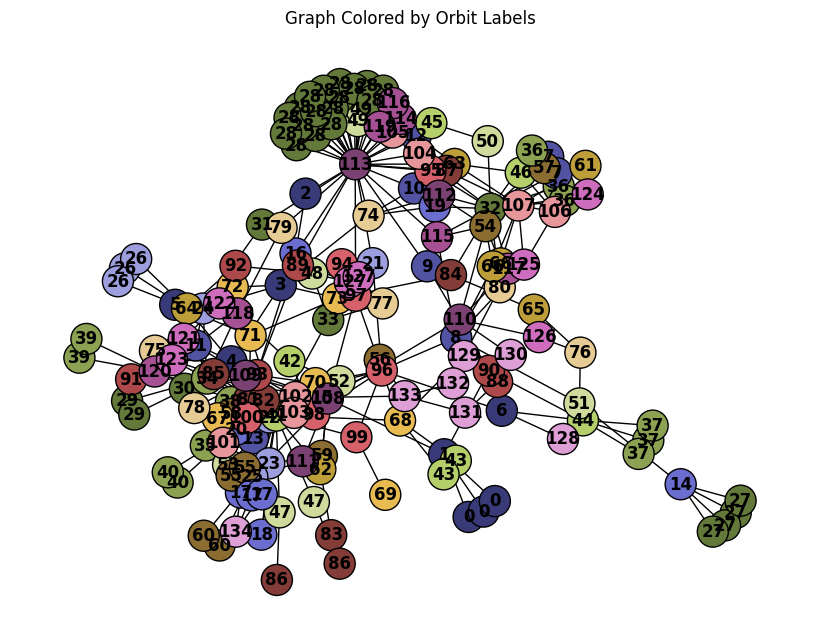

torch.Size([2, 12])
Non-distinguishable edges: 308


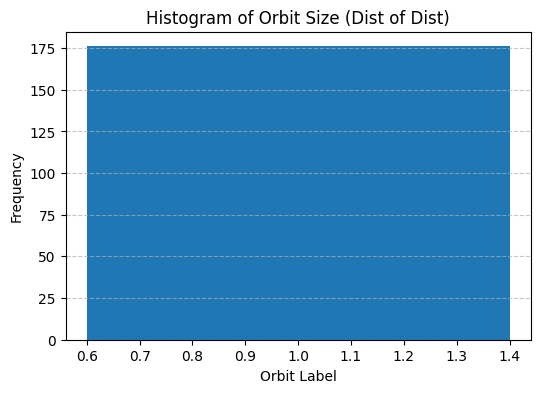

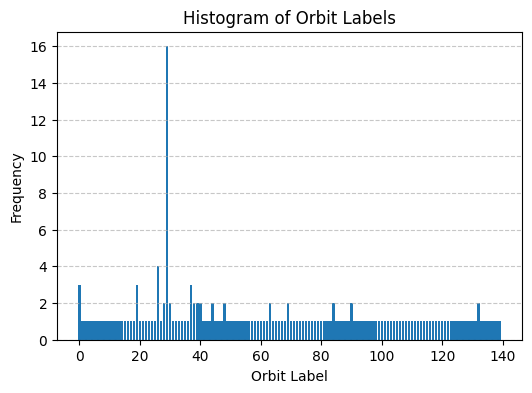

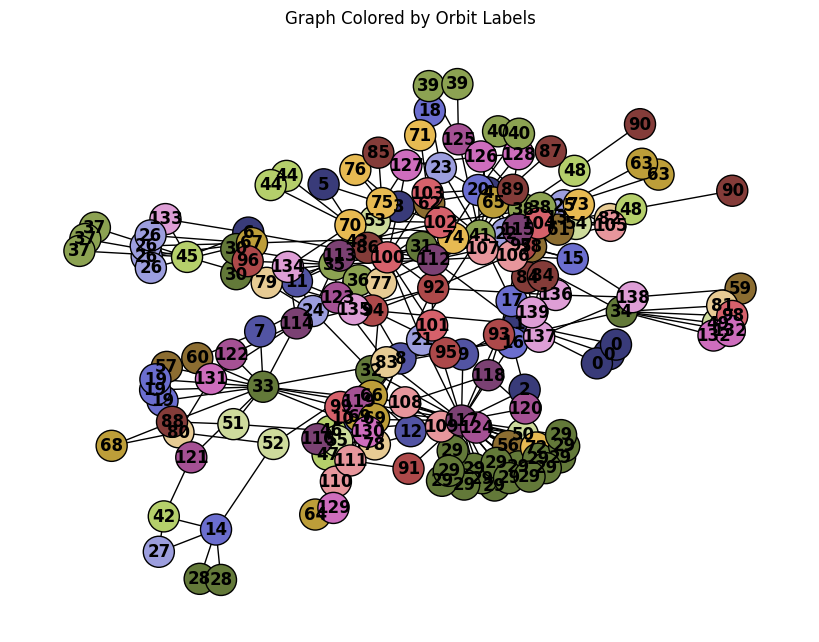

torch.Size([2, 18])
Non-distinguishable edges: 314


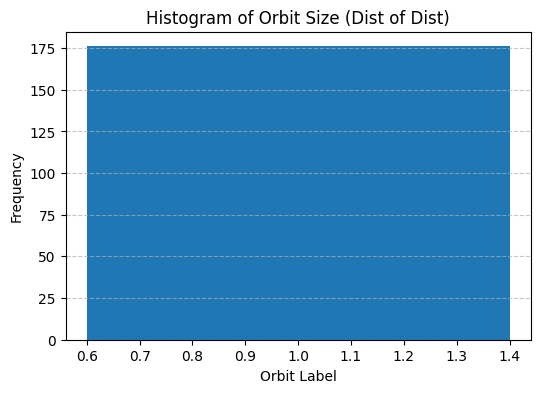

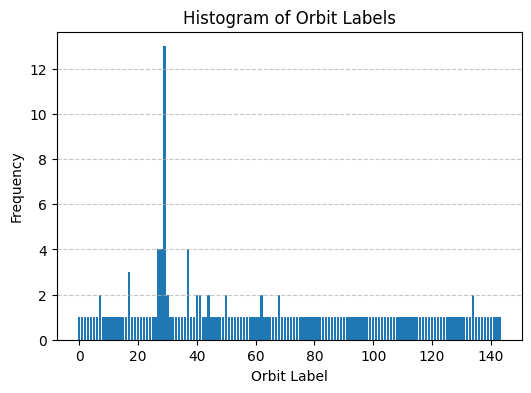

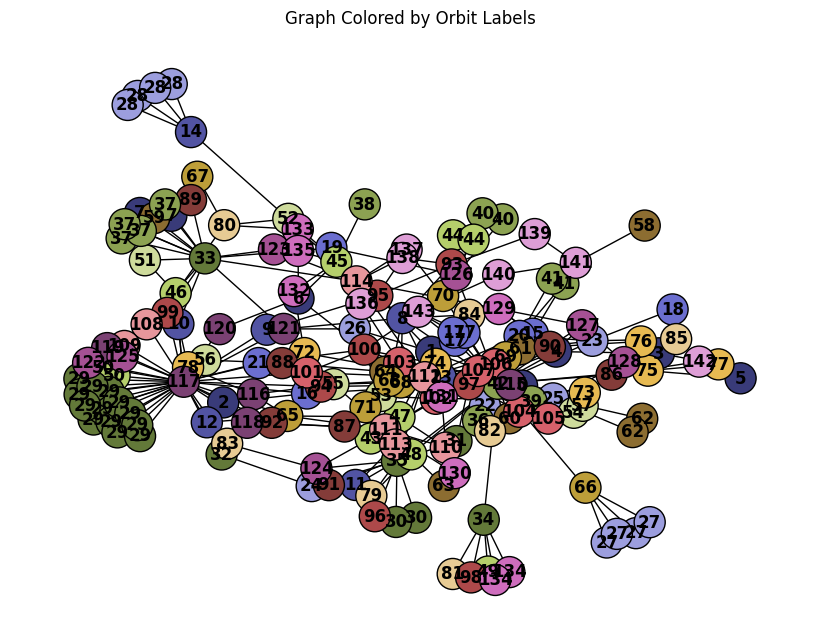

torch.Size([2, 24])
Non-distinguishable edges: 319


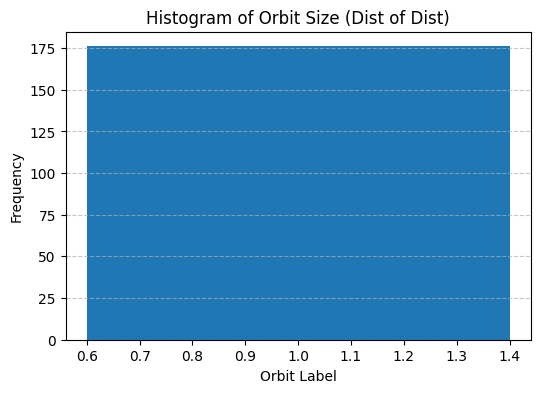

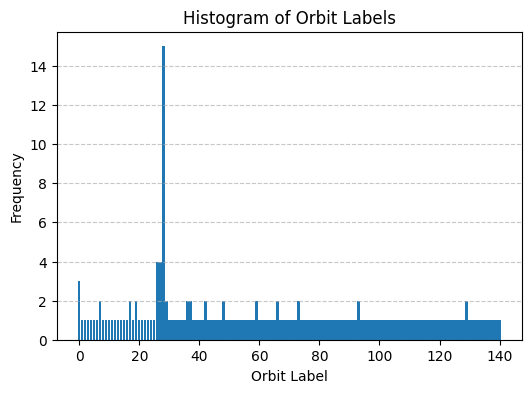

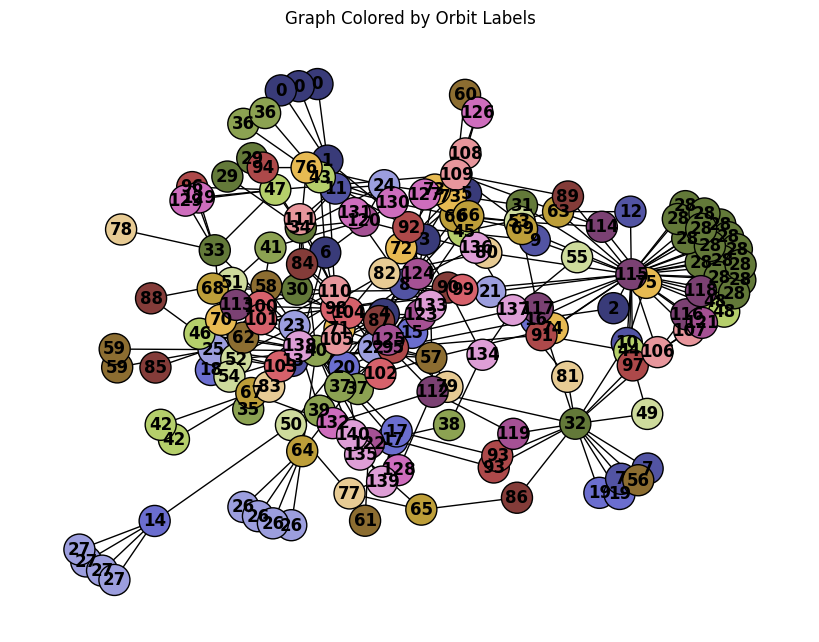

torch.Size([2, 30])
Non-distinguishable edges: 324


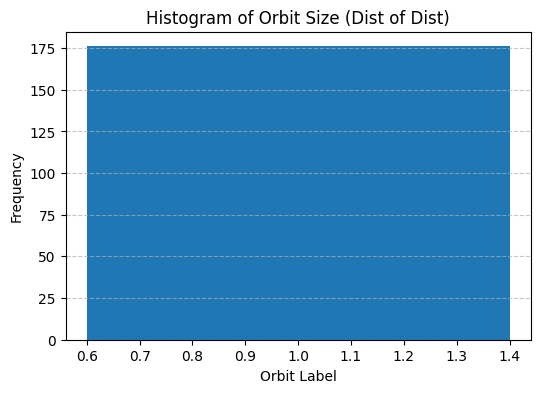

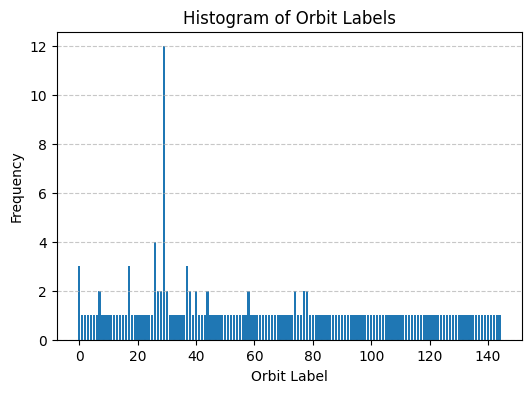

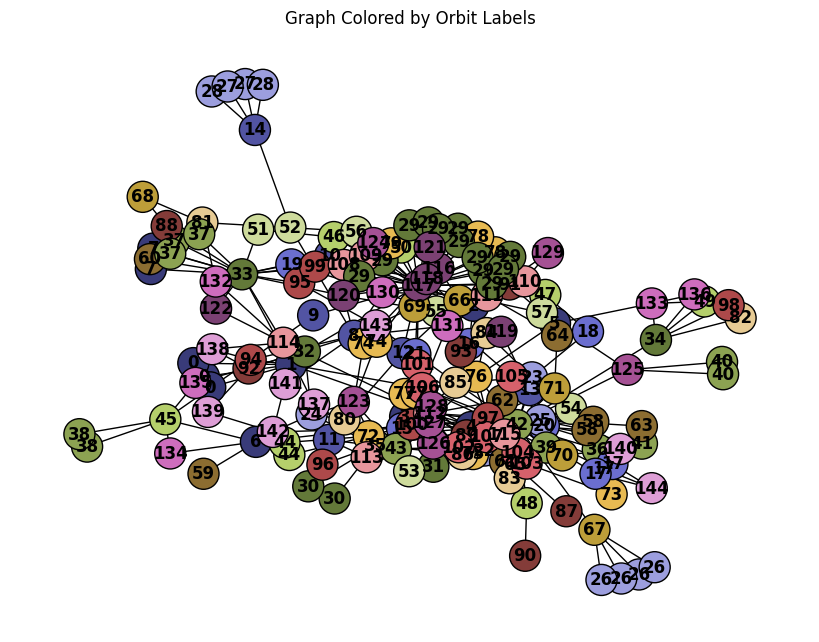

torch.Size([2, 36])
Non-distinguishable edges: 332


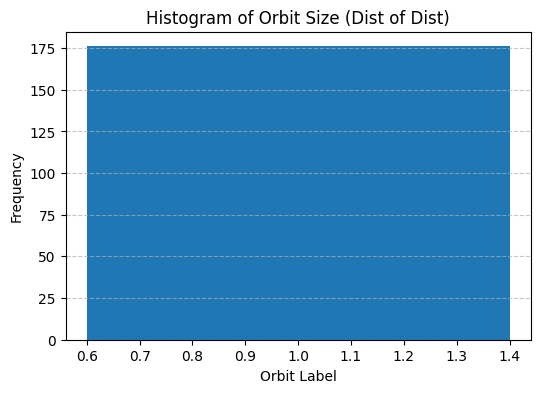

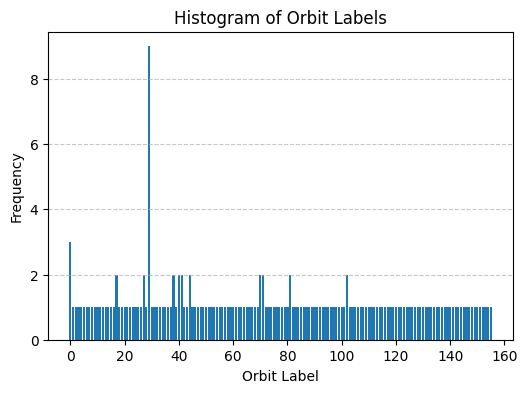

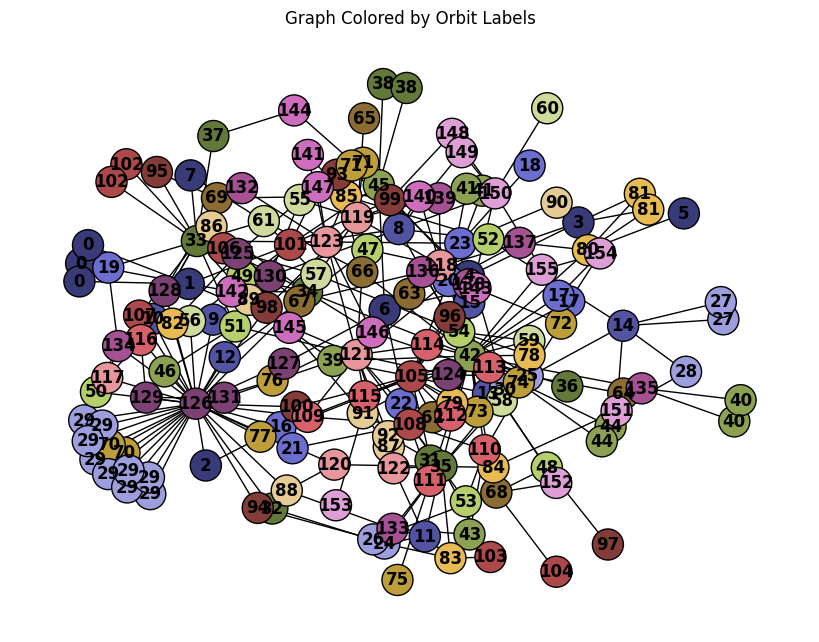

torch.Size([2, 42])
Non-distinguishable edges: 337


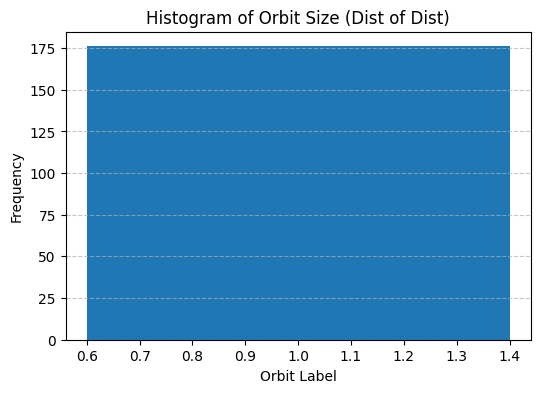

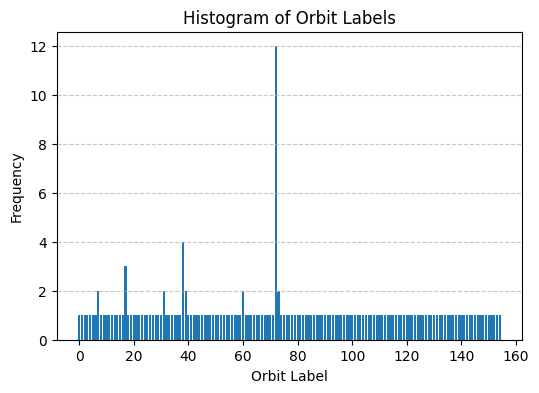

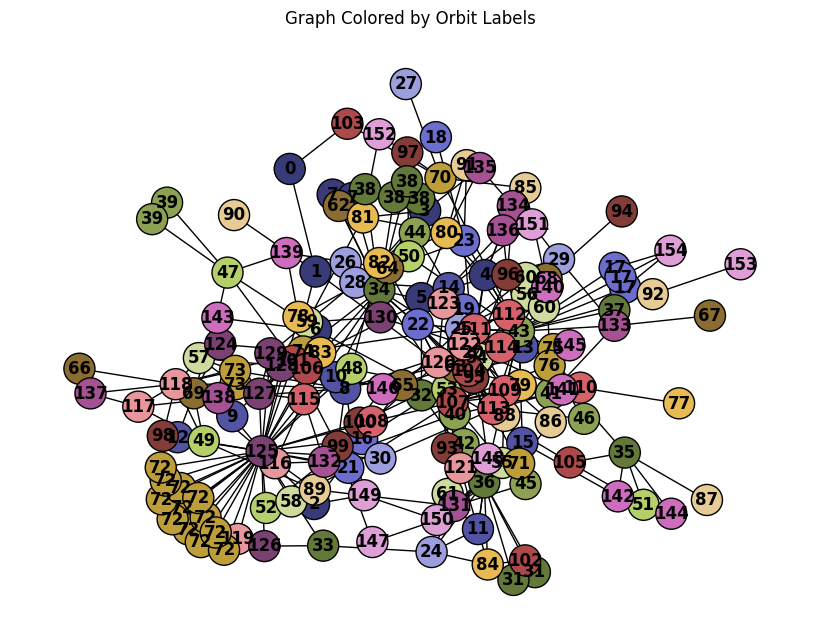

torch.Size([2, 48])
Non-distinguishable edges: 344


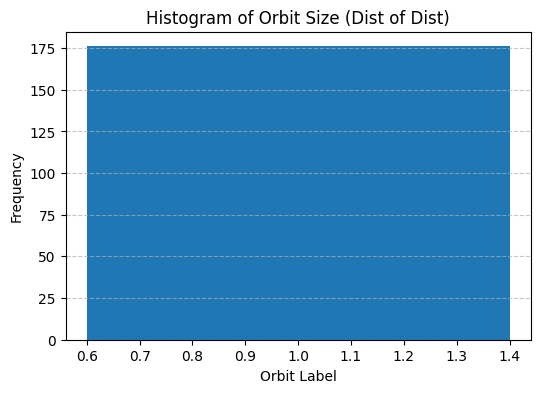

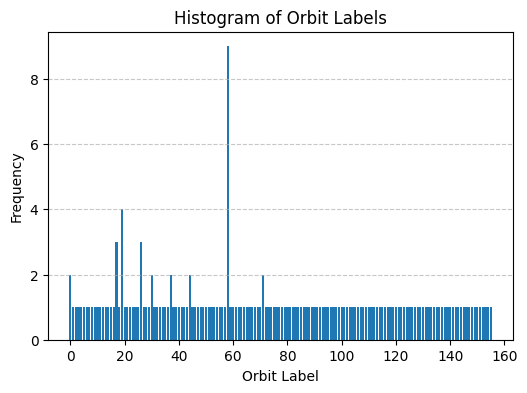

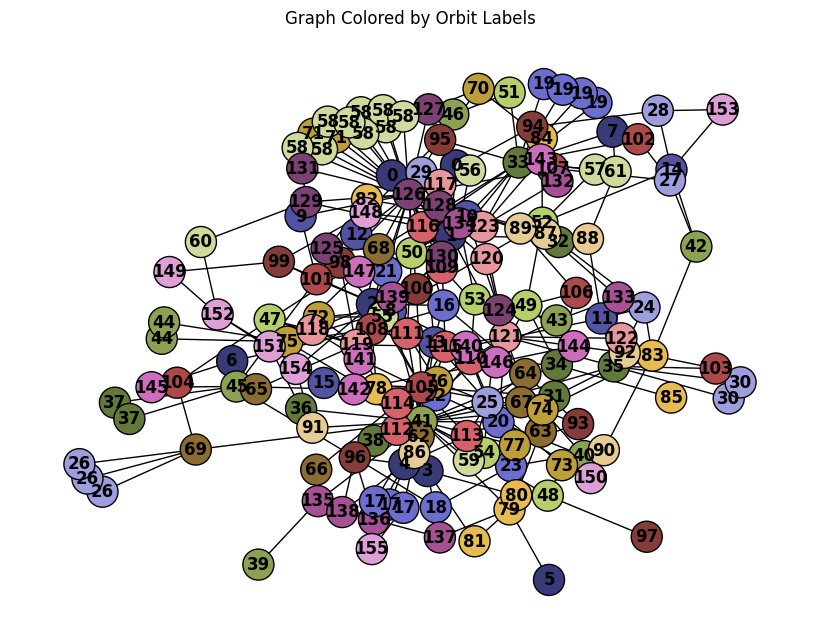

torch.Size([2, 54])
Non-distinguishable edges: 350


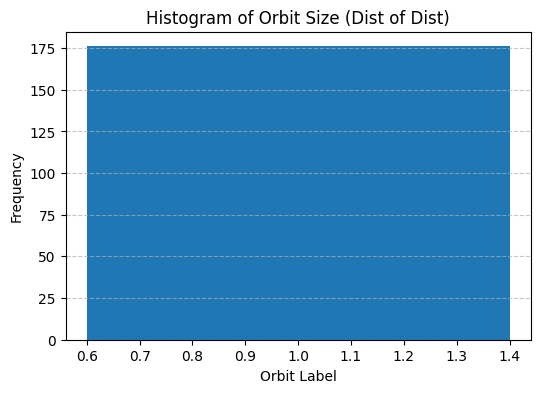

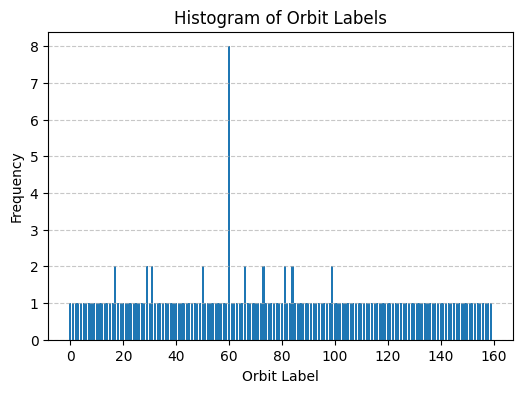

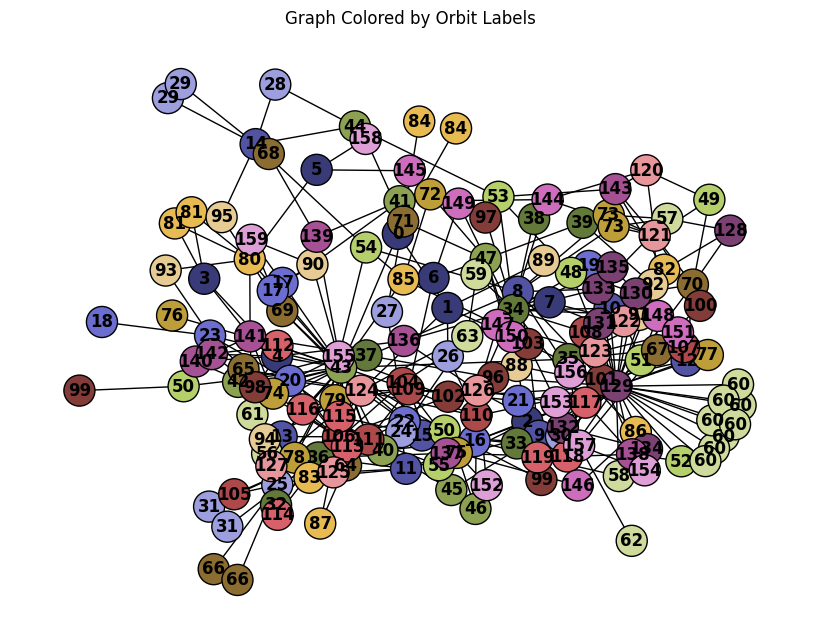

torch.Size([2, 60])
Non-distinguishable edges: 354


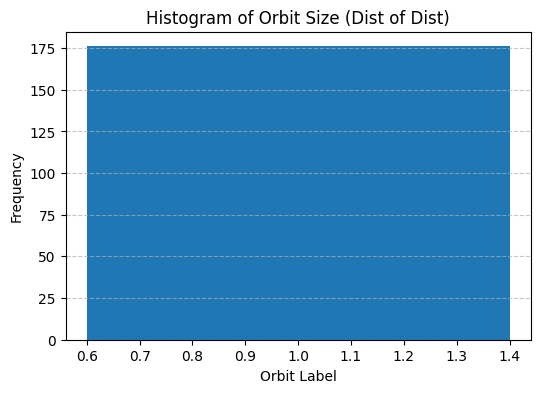

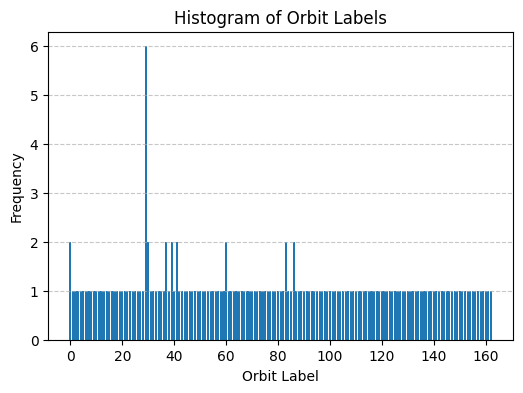

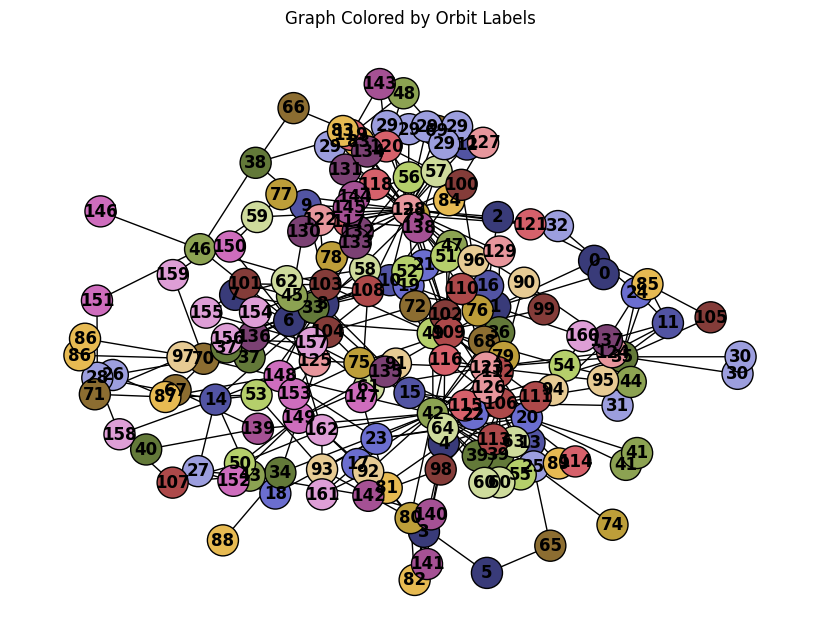

In [11]:
G = to_networkx(subgraph, to_undirected=True)

# Process Graph with WL Test
data = from_networkx(G)
print(f"Number of nodes in the graph: {data.num_nodes}")
analyze_automorphisms(G)
# mdata, mG = create_disjoint_graph(data)

inter_ratio = 1
intra_ratio = 1
total_edges = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
interval = 4
for edges in total_edges:
    if inter_ratio != 0 and intra_ratio != 0 and total_edges != 0:
        updated_graph_data, new_edges = add_random_edges(data, inter_ratio=inter_ratio, total_edges=edges*interval)
    else:
        updated_graph_data = data
    
    G = to_networkx(updated_graph_data, to_undirected=True)
    analyze_automorphisms(G)